# M2 — Gaze & DeepGaze workshop

**NTH bootcamp · Module 2**

The companion HTML page (`deepgaze-and-gaze.html`) walks through the *ideas* behind gaze prediction
and gaze-contingent phosphene rendering with no Python. This notebook does the *work*:

1. Run the real **DeepGaze III** model on a real image — heatmap, one fixation, a full scanpath.
2. Compute the saccade-length, saccade-angle and inhibition-of-return statistics the page
   showed schematically.
3. Drop the gaze signal into the real **`dynaphos`** phosphene simulator and visualise the
   "sliding effect" — scene-locked vs gaze-contingent rendering.
4. **The main experiment.** Walk a DeepGaze-sampled scanpath through `dynaphos`,
   accumulate the per-fixation phosphene images, and measure how well the cumulative
   reconstruction correlates with the original scene as a function of scanpath length and
   sampling strategy (DeepGaze vs random vs grid).

The notebook is a *resource*, not a workshop step — open it whenever you want the
hands-on version. Exercises are tagged `[easy]`, `[intermediate]`, and `[challenge]`.

## Setup

Install requirements. You need PyTorch, `deepgaze_pytorch`, and `dynaphos`. The first
cell is a one-time install — on a fresh kernel it takes ~2 min on CPU.

In [1]:
# One-time install. Safe to re-run; pip skips packages that are already up to date.
%pip install -q numpy matplotlib scipy scikit-image opencv-python einops torch torchvision
%pip install -q git+https://github.com/matthias-k/DeepGaze.git
%pip install -q dynaphos

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


A few imports, the device pick, and a small `show()` helper used throughout the notebook.

**Device:** if you have a CUDA GPU, this notebook will use it; otherwise it falls back to
CPU. Every tensor that touches DeepGaze goes through the `device` variable defined here, so
the same notebook runs unchanged on both.

**CLIP stub.** The `deepgaze_pytorch` package eagerly imports OpenAI's `clip` library
(for variants we don't use). We install a no-op stub before importing so the rest of the
notebook doesn't depend on it. Delete the two `sys.modules['clip'] = …` lines if you have
the real `clip` installed.

In [2]:
import os, sys, types, warnings, urllib.request, math
from pathlib import Path

# Stub `clip` so deepgaze_pytorch's top-level imports succeed without OpenAI CLIP.
sys.modules.setdefault('clip', types.ModuleType('clip'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import zoom
from scipy.special import logsumexp
from skimage.metrics import structural_similarity as ssim_metric
import cv2

import deepgaze_pytorch
import dynaphos
from dynaphos.cortex_models import get_visual_field_coordinates_probabilistically
from dynaphos.simulator import GaussianSimulator
from dynaphos.image_processing import sobel_processor

warnings.filterwarnings('ignore')  # torchvision pretrained-arg warnings, nothing actionable

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility helpers
RNG = np.random.default_rng(0)
torch.manual_seed(0)

# Image display helper — same shape as the CV notebook's show().
def show(*imgs, titles=None, cmap='gray', figsize=None, fovea=None):
    n = len(imgs)
    figsize = figsize or (4 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img in zip(axes, imgs):
        if img.ndim == 3:
            ax.imshow(img)
        else:
            ax.imshow(img, cmap=cmap)
        ax.set_xticks([]); ax.set_yticks([])
    if titles:
        for ax, t in zip(axes, titles):
            ax.set_title(t)
    if fovea is not None:
        x, y, r = fovea
        for ax in axes:
            ax.add_patch(mpatches.Circle((x, y), r, fill=False, color='red', lw=1.5))
    plt.tight_layout(); plt.show()

Using device: cpu


### Assets

We work at **256 × 256** throughout — small enough to keep DeepGaze and `dynaphos`
fast on CPU, large enough to see what's going on. Two source images:

- `bus.jpg` — already in `modules/assets/`, the same image you saw in M1.
- A second natural image with a face — downloaded on first run. DeepGaze was trained on
  humans looking at natural scenes and finds faces extremely well; this gives the cleanest
  "look where the model looks" demo.

We also fetch `centerbias_mit1003.npy` (the published MIT1003 Center Bias, ~8 MB) on
first run; subsequent runs read it from disk.

In [3]:
HERE = Path('.').resolve()
ASSETS = HERE / 'assets'
ASSETS.mkdir(exist_ok=True)

# Locate bus.jpg — it lives in the bootcamp's shared modules/assets folder.
BUS_CANDIDATES = [
    Path('../assets/bus.jpg'),                # when notebook is run from modules/deepgaze-and-gaze/
    Path('modules/assets/bus.jpg'),           # when run from repo root
    ASSETS / 'bus.jpg',                       # local fallback
]
BUS = next((p for p in BUS_CANDIDATES if p.exists()), None)
if BUS is None:
    BUS = ASSETS / 'bus.jpg'
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', BUS)
print('bus image:', BUS)

# Second image: a face/portrait. Public-domain Lenna-style portrait from scikit-image
# would be ideal but scikit-image's `astronaut` works for demonstration. Download here so
# the notebook is self-contained.
FACE = ASSETS / 'astronaut.png'
if not FACE.exists():
    from skimage import data
    import imageio.v3 as iio
    arr = data.astronaut()
    iio.imwrite(FACE, arr)
print('face image:', FACE)

# Center Bias
CB_PATH = ASSETS / 'centerbias_mit1003.npy'
if not CB_PATH.exists():
    print('downloading centerbias_mit1003.npy (~8 MB) ...')
    urllib.request.urlretrieve(
        'https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy',
        CB_PATH,
    )
print('center bias:', CB_PATH)

bus image: ..\assets\bus.jpg
face image: C:\Users\paple\OneDrive - Radboud Universiteit\PhD\Conferences\NTH DelftBootcamp\AIMD_bootcamp\modules\deepgaze-and-gaze\assets\astronaut.png
center bias: C:\Users\paple\OneDrive - Radboud Universiteit\PhD\Conferences\NTH DelftBootcamp\AIMD_bootcamp\modules\deepgaze-and-gaze\assets\centerbias_mit1003.npy


## 1 · DeepGaze III on a real image  *(real-Python version of HTML §02 + §04)*

DeepGaze III takes three inputs and returns a **log-probability map** the same size as the
image. The three inputs are:

1. The **image** itself (RGB, channel-first, batch dim).
2. The **Center Bias** — a fixed prior capturing the fact that humans fixate near the centre
   of an image more often than the edges, even before content matters. The default is fit on
   the MIT1003 eye-tracking dataset.
3. The **fixation history** — the last 4 fixations as `(x, y)` pixel coordinates. The model
   learned from data what humans tend to do *given* they just looked at a particular spot, so
   inhibition of return and natural saccade lengths fall out of this term automatically.

The output is a `log_density` tensor. Exponentiate to get back to the regular probability
map — `p = log_density.exp()`.

image: (256, 256, 3) tensor: (1, 3, 256, 256)


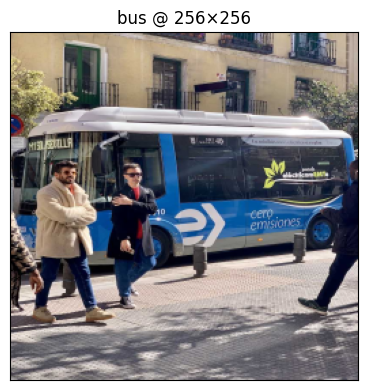

In [4]:
def load_image(path, size=256):
    '''Read an image, resize to (size, size), return both an HxWx3 uint8 array and an
    image tensor shaped (1, 3, H, W) on `device`.'''
    bgr = cv2.imread(str(path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    tensor = torch.tensor(rgb.transpose(2, 0, 1)[None].astype(np.float32)).to(device)
    return rgb, tensor

bus_rgb, bus_t = load_image(BUS, size=256)
H, W = bus_rgb.shape[:2]
print('image:', bus_rgb.shape, 'tensor:', tuple(bus_t.shape))
show(bus_rgb, titles=['bus @ 256×256'])

center bias shape: (256, 256) · exp sums to 0.9999999999999998


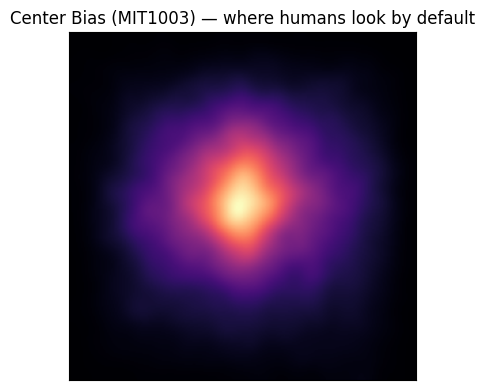

In [5]:
def build_centerbias(h, w, template_path=CB_PATH, uniform=False):
    '''Return a centerbias array of shape (h, w) as log-density (sums to 1 after exp).'''
    if uniform:
        cb = np.zeros((h, w), dtype=np.float64)
    else:
        template = np.load(template_path)
        cb = zoom(template, (h / template.shape[0], w / template.shape[1]),
                  order=0, mode='nearest')
    cb -= logsumexp(cb)  # normalise: exp(cb).sum() == 1
    return cb

cb = build_centerbias(H, W)
cb_t = torch.tensor(cb[None].astype(np.float32)).to(device)
print('center bias shape:', cb.shape, '· exp sums to', float(np.exp(cb).sum()))
show(np.exp(cb), titles=['Center Bias (MIT1003) — where humans look by default'], cmap='magma')

In [6]:
print('Loading DeepGaze III pretrained weights (one-time download ~80 MB) ...')
model = deepgaze_pytorch.DeepGazeIII(pretrained=True).to(device).eval()
print('model loaded; included_fixations =', model.included_fixations)

Loading DeepGaze III pretrained weights (one-time download ~80 MB) ...


Using cache found in C:\Users\paple/.cache\torch\hub\pytorch_vision_v0.6.0


model loaded; included_fixations = [-1, -2, -3, -4]


log_density min/max: -21.969414 -8.467313
probability sums to: 0.99999994


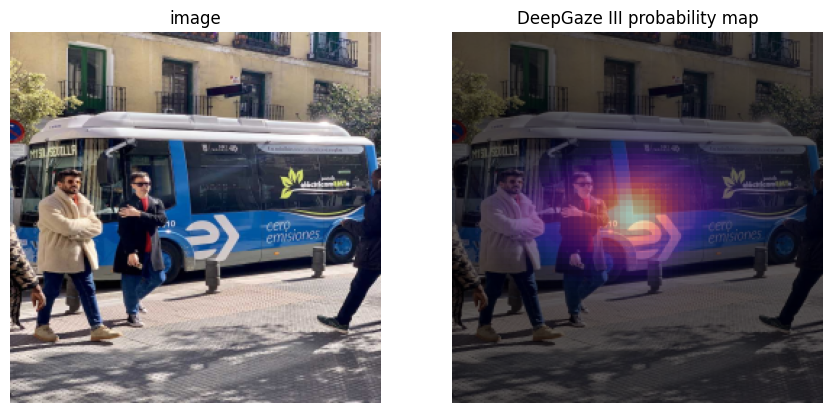

In [7]:
def deepgaze_density(image_tensor, centerbias_tensor, history_xy=None):
    '''Run DeepGaze III once. `history_xy` is a list of (x, y) tuples — the most recent
    fixations come LAST. If shorter than 4, we pad with the centre of the image.'''
    B, _, h, w = image_tensor.shape
    if history_xy is None:
        history_xy = []
    # Pad with image centre at the front so we always have 4 history points.
    centre = (w // 2, h // 2)
    padded = [centre] * (4 - len(history_xy)) + list(history_xy[-4:])
    xs = np.array([[p[0] for p in padded]], dtype=np.int64)
    ys = np.array([[p[1] for p in padded]], dtype=np.int64)
    xh = torch.tensor(xs[:, model.included_fixations]).to(device)
    yh = torch.tensor(ys[:, model.included_fixations]).to(device)
    with torch.no_grad():
        log_dens = model(image_tensor, centerbias_tensor, xh, yh)
    return log_dens.squeeze().detach().cpu().numpy()  # (H, W)

log_d = deepgaze_density(bus_t, cb_t, history_xy=None)
prob = np.exp(log_d)
prob /= prob.sum()
print('log_density min/max:', log_d.min(), log_d.max())
print('probability sums to:', prob.sum())

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].imshow(bus_rgb); axes[0].set_title('image'); axes[0].axis('off')
axes[1].imshow(bus_rgb); axes[1].imshow(prob, cmap='magma', alpha=0.65)
axes[1].set_title('DeepGaze III probability map'); axes[1].axis('off')
plt.tight_layout(); plt.show()

**A note on what we just computed.** Each pixel of the probability map says how likely the
next fixation lands there. The map is bigger and brighter near the bus's front windscreen
and the standing pedestrians — DeepGaze has learned that humans gravitate to faces, vehicles,
and high-contrast structure. The Center Bias contribution is the soft halo near the middle
that lifts the centre of the image even where content is sparse.

argmax fixation: (124, 124)
sampled fixation: (207, 123)


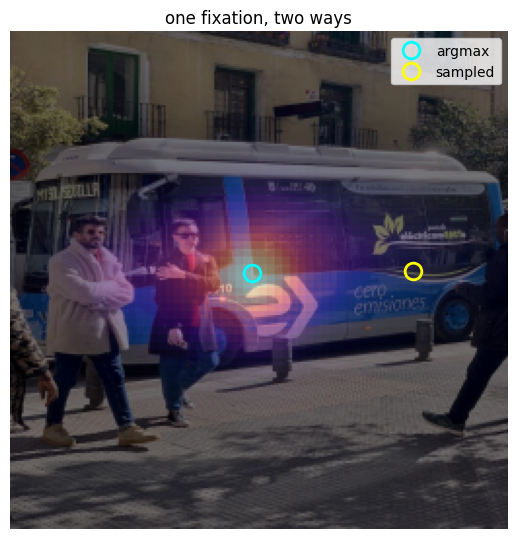

In [8]:
def sample_fixation(prob_map, rng=None):
    '''Sample one (x, y) point from a probability map (2D, sums to ~1).'''
    rng = rng or RNG
    flat = prob_map.ravel().astype(np.float64)
    flat /= flat.sum()
    idx = rng.choice(flat.size, p=flat)
    y, x = np.unravel_index(idx, prob_map.shape)
    return int(x), int(y)

x_arg, y_arg = np.unravel_index(prob.argmax(), prob.shape)[::-1]
x_smp, y_smp = sample_fixation(prob, np.random.default_rng(1))
print(f'argmax fixation: ({x_arg}, {y_arg})')
print(f'sampled fixation: ({x_smp}, {y_smp})')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(bus_rgb); ax.imshow(prob, cmap='magma', alpha=0.55)
ax.plot(x_arg, y_arg, 'o', color='cyan', ms=12, mfc='none', mew=2, label='argmax')
ax.plot(x_smp, y_smp, 'o', color='yellow', ms=12, mfc='none', mew=2, label='sampled')
ax.legend(loc='upper right'); ax.axis('off'); ax.set_title('one fixation, two ways')
plt.tight_layout(); plt.show()

### Exercise 1.1 — uniform vs MIT1003 Center Bias `[easy]`

Replace the MIT1003 Center Bias with a **uniform** prior and replot the probability map.
What changes, and what does that tell you about how much the page's "humans fixate near
the centre" prior was actually contributing?

*Hint: `build_centerbias(H, W, uniform=True)`.*

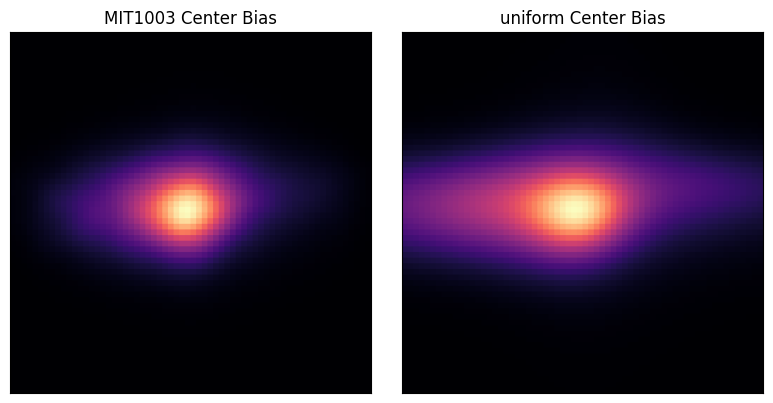

In [9]:
# Exercise 1.1 — uniform Center Bias
cb_uniform = build_centerbias(H, W, uniform=True)
cb_uniform_t = torch.tensor(cb_uniform[None].astype(np.float32)).to(device)
log_d_u = deepgaze_density(bus_t, cb_uniform_t)
prob_u = np.exp(log_d_u); prob_u /= prob_u.sum()

show(prob, prob_u, titles=['MIT1003 Center Bias', 'uniform Center Bias'], cmap='magma')

# In words: the MIT1003 map has a soft "halo" near the image centre even on bare road
# surface. The uniform map pushes all the mass onto content (the bus, the pedestrians) and
# strips the centre halo. Center Bias is roughly worth a soft Gaussian prior over middle
# pixels — small but non-trivial.

### Exercise 1.2 — argmax vs sampled fixation `[easy]`

You just saw the argmax and one sampled fixation differ. Sample **20 fixations from the
same probability map** (each independent — do not update the history) and overlay them on
the image. The argmax is a single deterministic point; the sample is a distribution. The
cloud you produce here is the *distribution of plausible first looks*.

*Hint: call `sample_fixation` in a loop with different rng seeds.*

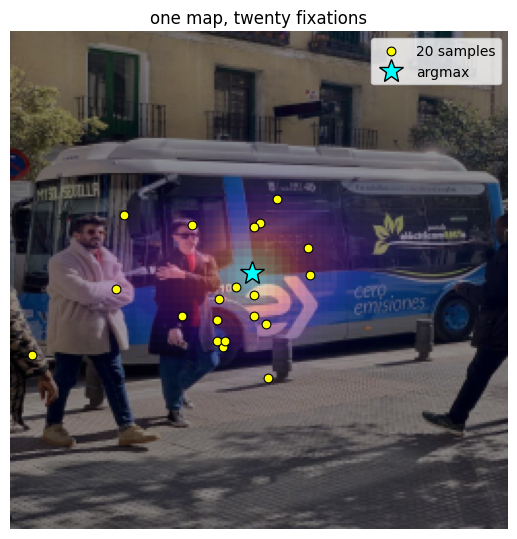

In [10]:
# Exercise 1.2 — 20 sampled fixations from the same probability map
xs, ys = [], []
for s in range(20):
    x, y = sample_fixation(prob, np.random.default_rng(100 + s))
    xs.append(x); ys.append(y)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(bus_rgb); ax.imshow(prob, cmap='magma', alpha=0.45)
ax.scatter(xs, ys, c='yellow', s=40, edgecolors='black', lw=0.8, label='20 samples')
ax.plot(x_arg, y_arg, '*', color='cyan', ms=18, mew=1, mec='black', label='argmax')
ax.legend(); ax.axis('off'); ax.set_title('one map, twenty fixations')
plt.tight_layout(); plt.show()

### Exercise 1.3 — does DeepGaze find the face? `[intermediate]`

Run DeepGaze III on the astronaut image and visualise the heatmap. Compare to the bus.
What happens to the probability mass when there's a face in the frame?

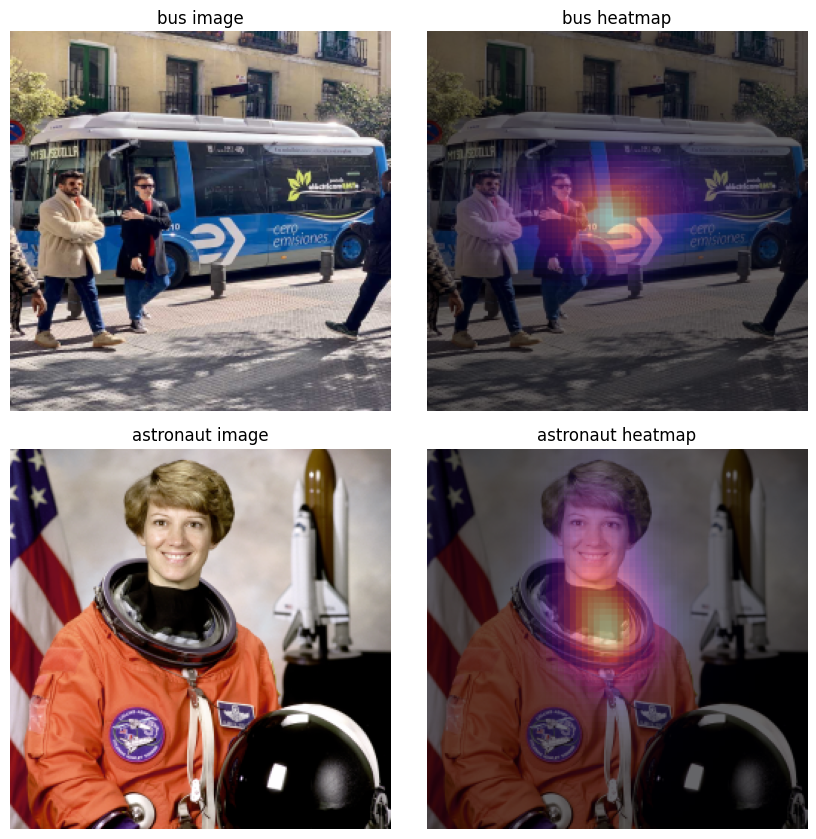

In [11]:
# Exercise 1.3 — astronaut (face) vs bus
face_rgb, face_t = load_image(FACE, size=256)
log_d_f = deepgaze_density(face_t, cb_t)
prob_f = np.exp(log_d_f); prob_f /= prob_f.sum()

fig, axes = plt.subplots(2, 2, figsize=(8.5, 8.5))
axes[0,0].imshow(bus_rgb); axes[0,0].set_title('bus image'); axes[0,0].axis('off')
axes[0,1].imshow(bus_rgb); axes[0,1].imshow(prob, cmap='magma', alpha=0.6)
axes[0,1].set_title('bus heatmap'); axes[0,1].axis('off')
axes[1,0].imshow(face_rgb); axes[1,0].set_title('astronaut image'); axes[1,0].axis('off')
axes[1,1].imshow(face_rgb); axes[1,1].imshow(prob_f, cmap='magma', alpha=0.6)
axes[1,1].set_title('astronaut heatmap'); axes[1,1].axis('off')
plt.tight_layout(); plt.show()

# Faces dominate the probability map — particularly the eyes and helmet visor. On the bus
# image, the mass is spread across faces of pedestrians, the windscreen (where a driver
# would be), and high-contrast edges. The face image is much more concentrated.

## 2 · Sampling scanpaths + statistics  *(real-Python version of HTML §05 + §06)*

One fixation is not a scanpath. To get a sequence: sample, update the history, re-run the
model, sample again. Repeat. The model's *output map* changes at every step — the recently
visited spots get suppressed (inhibition of return) and the surrounding region brightens.

`sample_scanpath()` below is the literal pseudocode from HTML §05.

In [12]:
def sample_scanpath(image_tensor, cb_tensor, n_fix=12, seed=0, start_xy=None):
    '''Run DeepGaze III repeatedly, sampling one fixation per step.'''
    rng = np.random.default_rng(seed)
    _, _, h, w = image_tensor.shape
    history = [start_xy or (w // 2, h // 2)]
    densities = []
    for _ in range(n_fix):
        log_d = deepgaze_density(image_tensor, cb_tensor, history)
        p = np.exp(log_d); p /= p.sum()
        densities.append(p)
        x, y = sample_fixation(p, rng)
        history.append((x, y))
    return history[1:], densities   # drop the seed centre fixation

path, densities = sample_scanpath(bus_t, cb_t, n_fix=12, seed=0)
print('scanpath length:', len(path))
print('first few fixations:', path[:4])

scanpath length: 12
first few fixations: [(109, 131), (107, 109), (132, 70), (158, 35)]


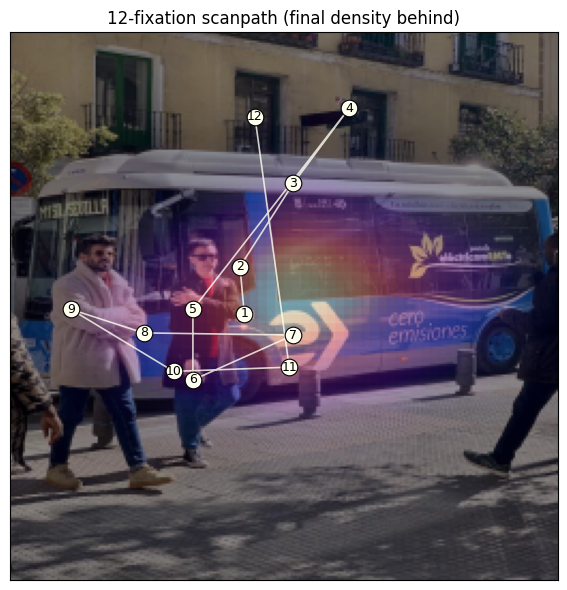

In [13]:
def plot_scanpath(image, path, density=None, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    if density is not None:
        ax.imshow(density, cmap='magma', alpha=0.45)
    xs = [p[0] for p in path]; ys = [p[1] for p in path]
    ax.plot(xs, ys, '-', color='ivory', lw=1.2, alpha=0.8)
    for i, (x, y) in enumerate(path, 1):
        ax.plot(x, y, 'o', color='ivory', mec='black', mew=0.8, ms=12)
        ax.text(x, y, str(i), color='black', ha='center', va='center', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)

plot_scanpath(bus_rgb, path, densities[-1], title='12-fixation scanpath (final density behind)')
plt.tight_layout(); plt.show()

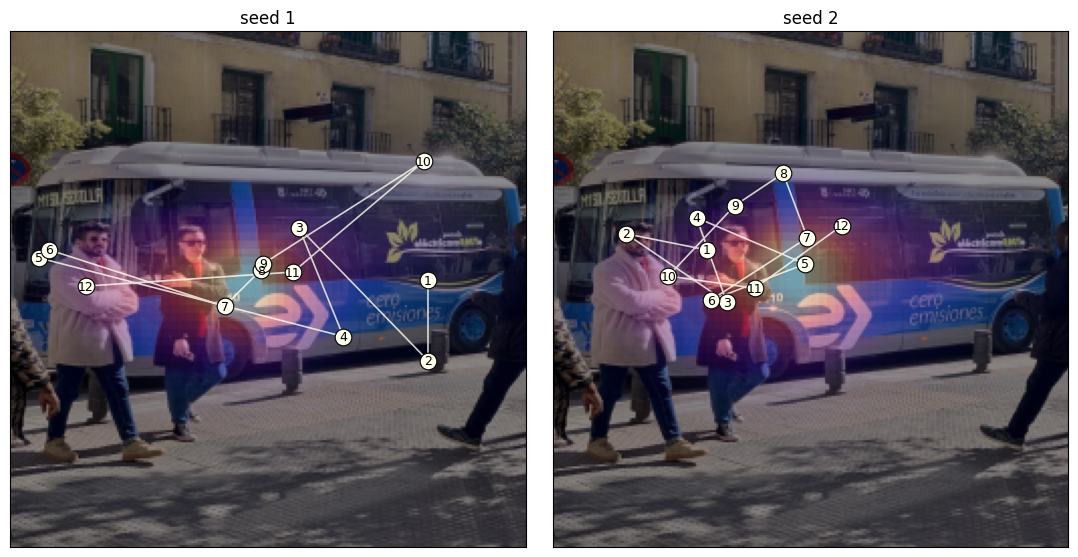

In [14]:
# "Run play twice. Same scanpath?" — two seeds side by side.
path_a, dens_a = sample_scanpath(bus_t, cb_t, n_fix=12, seed=1)
path_b, dens_b = sample_scanpath(bus_t, cb_t, n_fix=12, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_scanpath(bus_rgb, path_a, dens_a[-1], ax=axes[0], title='seed 1')
plot_scanpath(bus_rgb, path_b, dens_b[-1], ax=axes[1], title='seed 2')
plt.tight_layout(); plt.show()

The two scanpaths visit overlapping regions (both stop on the bus front and on a
pedestrian) but differ in order and exact landing points. That's the whole point of
sampling — DeepGaze gives you a *distribution* over plausible viewers, not a single canonical
trace.

### Exercise 2.1 — saccade-length distribution `[easy]`

Run 50 scanpaths of length 8 each on the bus and pool all the saccade lengths (Euclidean
distance between consecutive fixations). Plot a histogram. Compare to the HTML §06
saccade-length distribution — it should be skewed: many short jumps, fewer long ones.

*Hint: 50 × 8 = 400 saccades is plenty. Use different seeds, then `np.hypot` for distances.*

n saccades: 350, mean: 58.1px, median: 52.2px


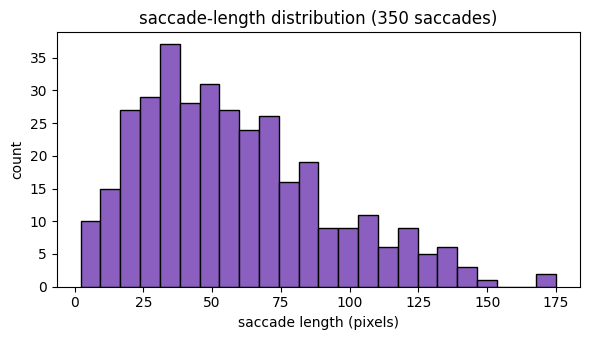

In [15]:
# Exercise 2.1 — saccade-length histogram across 50 scanpaths
lengths = []
for s in range(50):
    p, _ = sample_scanpath(bus_t, cb_t, n_fix=8, seed=10 + s)
    xs = np.array([f[0] for f in p]); ys = np.array([f[1] for f in p])
    dx = np.diff(xs); dy = np.diff(ys)
    lengths.extend(np.hypot(dx, dy).tolist())

print(f'n saccades: {len(lengths)}, mean: {np.mean(lengths):.1f}px, median: {np.median(lengths):.1f}px')
plt.figure(figsize=(6, 3.5))
plt.hist(lengths, bins=24, color='#8b5fbf', edgecolor='black')
plt.xlabel('saccade length (pixels)'); plt.ylabel('count')
plt.title(f'saccade-length distribution ({len(lengths)} saccades)')
plt.tight_layout(); plt.show()

### Exercise 2.2 — inhibition of return, empirically `[intermediate]`

Compare the probability map **before any fixation** vs **after one fixation at the
argmax**. Plot the *difference*. You should see a dark hole punched at and around the first
fixation, with brightness slightly redistributed to the periphery.

*Hint: `deepgaze_density(bus_t, cb_t, history_xy=None)` for the "before" map and
`deepgaze_density(bus_t, cb_t, history_xy=[(x_arg, y_arg)])` for "after". Plot
`after - before` with a diverging colormap.*

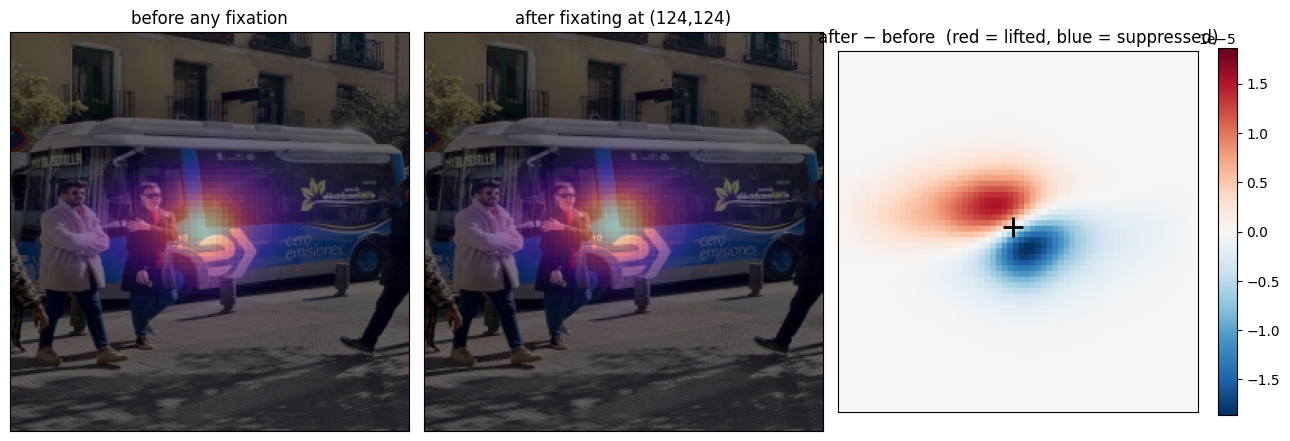

In [16]:
# Exercise 2.2 — heatmap before vs after the argmax fixation
before = np.exp(deepgaze_density(bus_t, cb_t)); before /= before.sum()
after  = np.exp(deepgaze_density(bus_t, cb_t, history_xy=[(x_arg, y_arg)])); after /= after.sum()
diff = after - before

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(bus_rgb); axes[0].imshow(before, cmap='magma', alpha=0.6); axes[0].set_title('before any fixation')
axes[1].imshow(bus_rgb); axes[1].imshow(after,  cmap='magma', alpha=0.6); axes[1].set_title(f'after fixating at ({x_arg},{y_arg})')
vlim = float(np.abs(diff).max())
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vlim, vmax=vlim)
axes[2].plot(x_arg, y_arg, '+', color='black', ms=14, mew=2)
axes[2].set_title('after − before  (red = lifted, blue = suppressed)')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

### Exercise 2.3 — saccade angles `[intermediate]`

Compute the **angle of each saccade relative to the previous one** (in radians) across many
scanpaths and histogram it. Real humans (and DeepGaze) keep going in roughly the same
direction more often than they double back — you should see a bump near 0 and dips near ±π.

*Hint: for three consecutive fixations A→B→C, the turn angle is `atan2(C.y-B.y, C.x-B.x) -
atan2(B.y-A.y, B.x-A.x)`, wrapped into (-π, π].*

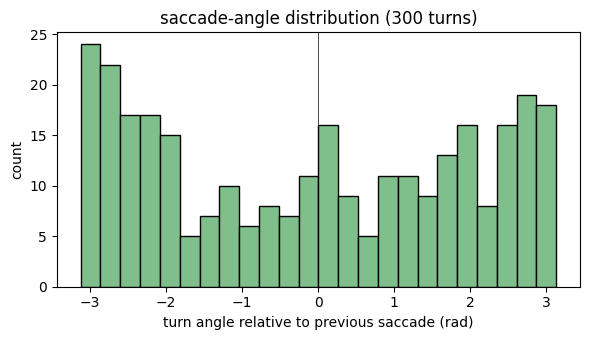

In [17]:
# Exercise 2.3 — saccade-angle histogram across 50 scanpaths
angles = []
for s in range(50):
    p, _ = sample_scanpath(bus_t, cb_t, n_fix=8, seed=200 + s)
    p = np.array(p)
    if len(p) < 3:
        continue
    v = np.diff(p, axis=0)               # saccade vectors (n-1, 2)
    a = np.arctan2(v[:, 1], v[:, 0])     # heading per saccade
    da = np.diff(a)                      # turn angle between consecutive saccades
    da = (da + np.pi) % (2 * np.pi) - np.pi
    angles.extend(da.tolist())

plt.figure(figsize=(6, 3.5))
plt.hist(angles, bins=24, color='#7fbf8b', edgecolor='black')
plt.xlabel('turn angle relative to previous saccade (rad)')
plt.ylabel('count'); plt.title(f'saccade-angle distribution ({len(angles)} turns)')
plt.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

## 3 · Phosphene rendering with `dynaphos`

So far we have not touched a phosphene. Time to plug a real simulator in.

[`dynaphos`](https://github.com/neuralcodinglab/dynaphos) (van der Grinten et al., *eLife*
2024) is a biologically grounded forward model of cortical phosphene perception. Each
electrode lives on the cortex; through a cortical-magnification mapping it projects to a
*phosphene location* in the visual field. Stimulating an electrode produces a Gaussian
blob centred at that visual-field location whose brightness and size depend on the current
amplitude.

We embed the published `params.yaml` as a Python dict so you can see (and tweak) every
knob without leaving the notebook.

In [18]:
# Default dynaphos parameters (copy of config/params.yaml from neuralcodinglab/dynaphos,
# with `run.resolution` set to [256, 256] to match the image size we picked in §0).
DYNAPHOS_PARAMS = {
    'run': {
        'resolution': [256, 256], 'view_angle': 16, 'origin': [0, 0],
        'min_angle': 0.001, 'fps': 35, 'gpu': 0, 'print_stats': False,
        'seed': 42, 'dtype': 'float32', 'use_gaussian_lut': False, 'batch_size': 0,
    },
    'display': {
        'screen_resolution': [1920, 1080], 'screen_diagonal': 13.3,
        'dist_to_screen': 600,
    },
    'sampling': {
        'sampling_method': 'receptive_fields', 'RF_size': 0.5,
        'stimulus_scale': 1.0e-4,
    },
    'cortex_model': {
        'model': 'dipole', 'k': 17.3, 'a': 0.75, 'b': 120, 'alpha': 0.95,
        'dropout_rate': 0.2, 'noise_scale': 0.4,
    },
    'temporal_dynamics': {
        'trace_increase_rate': 13.95528162,
        'activation_decay_per_second': 0.00012340980408667956,
        'trace_decay_per_second': 0.99949191,
    },
    'size': {
        'size_equation': 'sqrt', 'MD': 0.7, 'I_half': 40, 'slope_size': 0.08,
        'current_spread': 6.75e-4, 'radius_to_sigma': 0.5,
    },
    'brightness_saturation': {
        'cps_half': 1.057631326853325e-07,
        'slope_brightness': 19152642.500946816,
    },
    'thresholding': {
        'use_threshold': True, 'rheobase': 2.39e-5,
        'activation_threshold': 9.141886000943878e-08,
        'activation_threshold_sd': 6.715877869833961e-08,
    },
    'default_stim': {
        'relative_stim_duration': 1, 'pw_default': 1.7e-4, 'freq_default': 300,
    },
    'gabor': {'gabor_filtering': False, 'gamma': 1.5},
}

def make_simulator(n_phosphenes=500, seed=0, params=None):
    p = params or DYNAPHOS_PARAMS
    rng = np.random.default_rng(seed)
    coords = get_visual_field_coordinates_probabilistically(p, n_phosphenes, rng=rng)
    sim = GaussianSimulator(p, coords, rng=rng)
    sim._coords = coords   # keep the Map handy for inspection (not stored by dynaphos)
    return sim

sim = make_simulator(n_phosphenes=500)
xs_vf, ys_vf = sim._coords.cartesian
print(f'simulator built · {sim.num_phosphenes} phosphenes · '
      f'visual-field x range [{xs_vf.min():+.1f}, {xs_vf.max():+.1f}] deg')

simulator built · 500 phosphenes · visual-field x range [-7.6, +7.5] deg


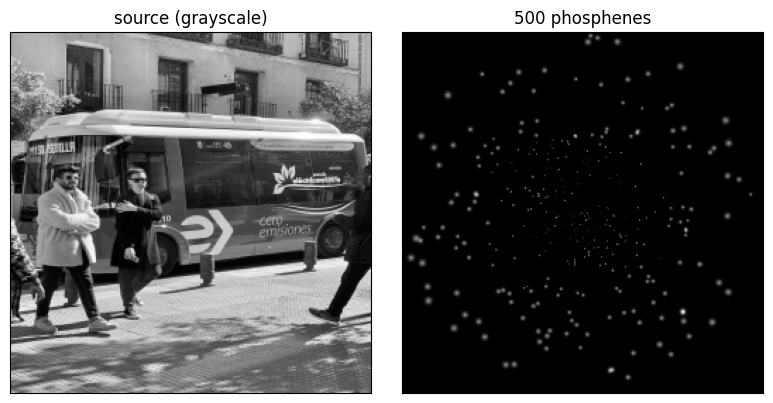

In [19]:
def render_phosphenes(sim, image_2d):
    '''Apply `dynaphos` to a 2D image and return the rendered phosphene image.'''
    if image_2d.dtype != np.float32:
        image_2d = image_2d.astype(np.float32)
    if image_2d.max() > 1.5:
        image_2d = image_2d / 255.0
    sim.reset()
    stim = sim.sample_stimulus(image_2d, rescale=True)
    sim.update(amplitude=stim)
    activations = sim.gaussian_activation()                # (n_phos, H, W)
    return activations.sum(0).detach().cpu().numpy()        # (H, W)

bus_gray = cv2.cvtColor(bus_rgb, cv2.COLOR_RGB2GRAY)
phos = render_phosphenes(sim, bus_gray)
show(bus_gray, phos, titles=['source (grayscale)', f'500 phosphenes'], cmap='gray')

### Exercise 3.1 — bandwidth vs picture quality `[easy]`

A real cortical implant has ~100–1000 electrodes. Render the same bus image at 100, 500,
and 1000 phosphenes and plot them side by side. Where is the elbow — at what electrode
count does the bus become recognisable?

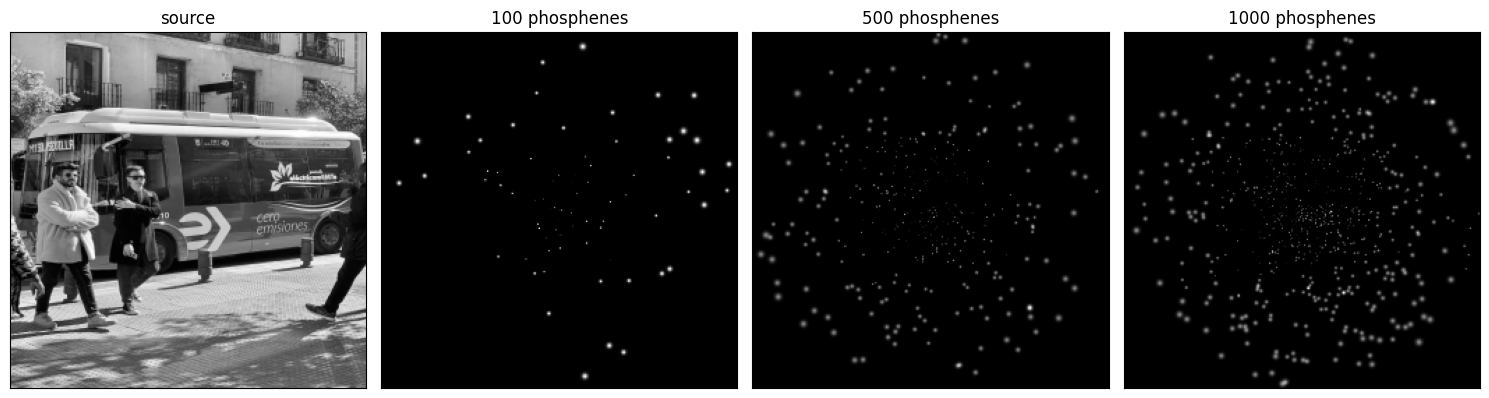

In [20]:
# Exercise 3.1 — vary electrode count
images, titles = [bus_gray], ['source']
for n in (100, 500, 1000):
    s = make_simulator(n_phosphenes=n, seed=0)
    images.append(render_phosphenes(s, bus_gray))
    titles.append(f'{n} phosphenes')
show(*images, titles=titles, cmap='gray', figsize=(15, 4.2))

### Exercise 3.2 — what does an edge map look like through phosphenes? `[intermediate]`

`dynaphos` ships with a Sobel processor (`sobel_processor`) — the same idea as the M1
edge detector. Pass the **edge map** of the bus through phosphenes instead of raw
intensities. Sparse edges + sparse phosphenes is the realistic prosthesis pipeline; raw
intensity is a sanity baseline.

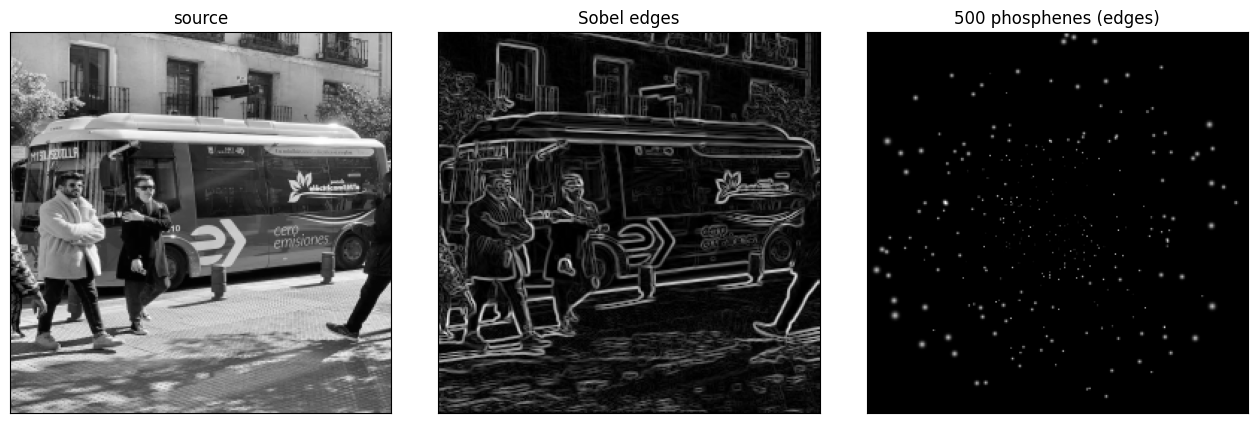

In [21]:
# Exercise 3.2 — edge map → phosphenes
edges = sobel_processor(bus_gray.astype(np.float32))
edges_norm = edges / max(edges.max(), 1e-6)
sim500 = make_simulator(n_phosphenes=500, seed=0)
phos_edges = render_phosphenes(sim500, edges_norm)

show(bus_gray, edges_norm, phos_edges,
     titles=['source', 'Sobel edges', '500 phosphenes (edges)'], cmap='gray', figsize=(13, 4.2))

## 4 · Gaze + phosphenes — the main experiment

The HTML page (§01) frames the **sliding effect**: each phosphene is tied to a fixed
location in the visual field, *not* in the world. If the prosthesis streams the camera
feed naively, every saccade drags the whole scene across the user's visual field. To fix
this, the pipeline has to be **gaze-contingent** — re-render so the same patch of the world
stays anchored to the same point in the world even as the eye moves.

We do two experiments:

**§4a — Qualitative.** Show the sliding effect by comparing naive vs gaze-contingent
rendering at a few fixations from a sampled scanpath.

**§4b — Quantitative.** Walk a scanpath through the simulator one fixation at a time,
accumulate the per-fixation phosphene images, and measure how close the cumulative
reconstruction gets to the original scene as a function of *scanpath length* and *strategy*
(DeepGaze vs random vs grid).

### 4a · The sliding effect

The user's gaze always lands at the centre of *their* visual field — that's where the fovea
is. So the prosthesis needs to render the world such that whatever the user is looking at
ends up at the centre of the phosphene grid. We implement this with a `foveate` helper:
given the camera frame + a fixation point, it returns a centred view of the world around
that fixation, dark outside a "useful field of view" radius.

demo fixations: [(109, 131), (158, 35), (132, 141), (76, 158)]


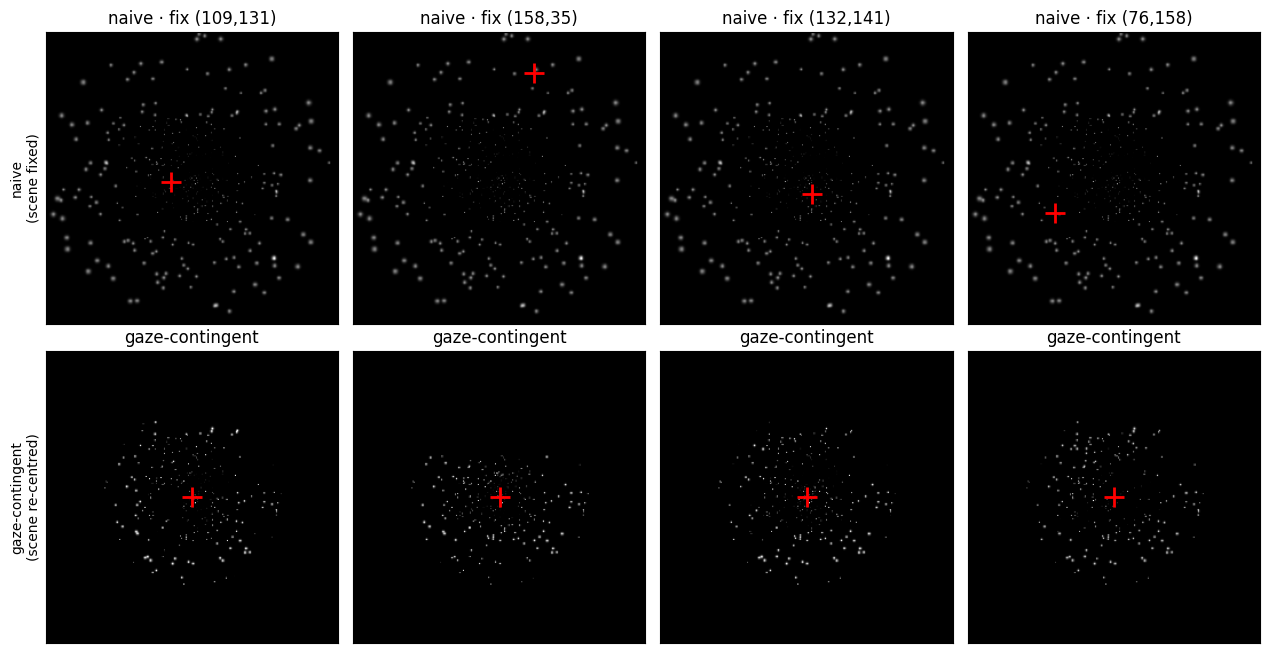

In [22]:
def foveate(image, xy, fov_radius=64, output_size=None):
    '''Translate `image` so that `xy` is at the centre, then mask to a soft disc.'''
    if image.ndim == 3:
        h, w, _ = image.shape
    else:
        h, w = image.shape
    output_size = output_size or (h, w)
    th, tw = output_size
    fx, fy = xy
    # Shift so (fx, fy) lands at (tw/2, th/2)
    M = np.float32([[1, 0, tw / 2 - fx], [0, 1, th / 2 - fy]])
    shifted = cv2.warpAffine(image, M, (tw, th), borderValue=0)
    # Soft circular mask
    yy, xx = np.ogrid[:th, :tw]
    r = np.hypot(xx - tw / 2, yy - th / 2)
    mask = np.clip(1.0 - (r - fov_radius) / 12.0, 0, 1)
    if shifted.ndim == 3:
        mask = mask[..., None]
    return (shifted.astype(np.float32) * mask).astype(shifted.dtype)

# Take 4 evenly-spaced fixations from the seed-0 scanpath we already have
sample_idx = [0, 3, 6, 9]
fixations = [path[i] for i in sample_idx]
print('demo fixations:', fixations)

sim_demo = make_simulator(n_phosphenes=500, seed=0)
fig, axes = plt.subplots(2, len(fixations), figsize=(3.2 * len(fixations), 6.6))
for j, (fx, fy) in enumerate(fixations):
    naive = render_phosphenes(sim_demo, bus_gray)  # entire scene, gaze ignored
    foved = foveate(bus_gray, (fx, fy), fov_radius=64)
    smart = render_phosphenes(sim_demo, foved)
    axes[0, j].imshow(naive, cmap='gray')
    axes[0, j].plot(fx, fy, '+', color='red', ms=14, mew=2)
    axes[0, j].set_title(f'naive · fix ({fx},{fy})')
    axes[1, j].imshow(smart, cmap='gray')
    axes[1, j].plot(W / 2, H / 2, '+', color='red', ms=14, mew=2)
    axes[1, j].set_title('gaze-contingent')
    for ax in (axes[0, j], axes[1, j]):
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('naive\n(scene fixed)', fontsize=10)
axes[1, 0].set_ylabel('gaze-contingent\n(scene re-centred)', fontsize=10)
plt.tight_layout(); plt.show()

**What you should see.** Top row: the phosphene image is identical at every fixation,
because the naive renderer ignores gaze. The red `+` marks where the user is looking — and
it drifts across the rendered image. That's the sliding effect: the user perceives the
scene as anchored to *the eye*, not the world.

Bottom row: every frame re-centres the relevant patch of the world to the fovea. The user
"sees" what they're attending to, and everything outside their useful field of view is
dark. The cost is bandwidth — only a foveated patch is rendered, so we are betting the
attended region is the informative one. That's exactly what DeepGaze gives us a model of.

### 4b · Cumulative reconstruction

Here's the experiment. For each fixation along a scanpath:

1. Take a **foveated view** of the world centred at that fixation.
2. Pass it through `dynaphos` to get a phosphene image $P_i$ — in world coordinates.
3. **Accumulate** into a running canvas $C_i = \max(C_{i-1}, P_i)$ — per-pixel max keeps
   the brightest reading seen at each location.
4. Plot $C_i$ at a few milestones, and measure similarity to the original scene
   (correlation + SSIM) as a function of fixation count.

Then we **compare three strategies**: DeepGaze (informed attention), uniform random
fixations, and a regular grid scan.

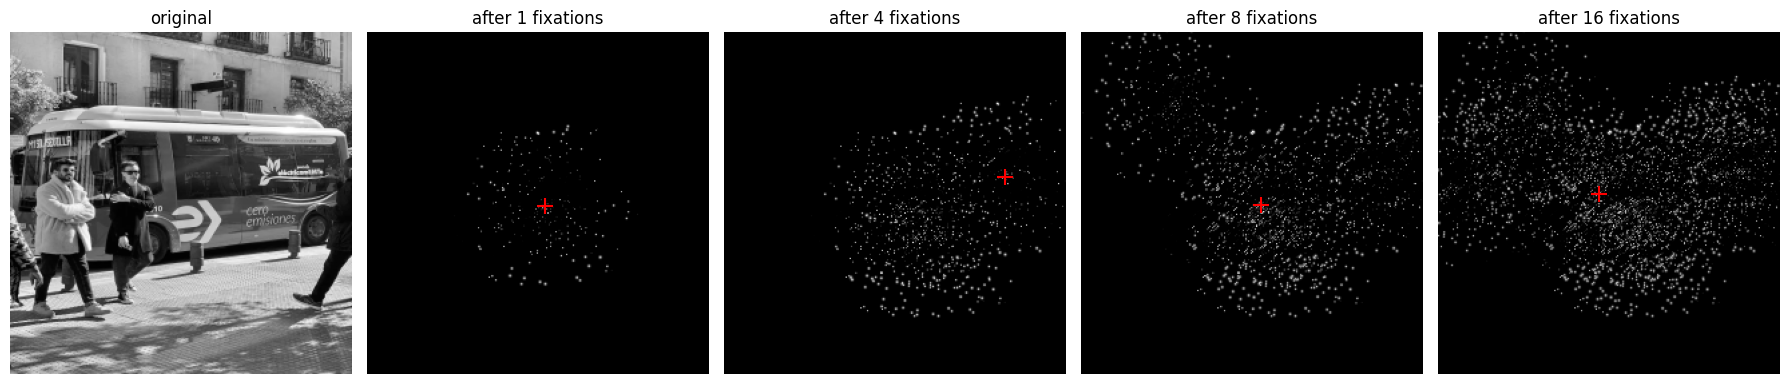

In [23]:
def accumulate(prev, new, mode='max'):
    if prev is None:
        return new.copy()
    if mode == 'max':
        return np.maximum(prev, new)
    if mode == 'sum':
        return prev + new
    if mode == 'mean':
        return None  # handled in the caller (needs a counter)
    raise ValueError(mode)

def walk(image_gray, scanpath, sim, fov_radius=64, mode='max'):
    '''Yield the cumulative reconstruction after each fixation.'''
    canvas = None
    history = []
    for xy in scanpath:
        foved = foveate(image_gray, xy, fov_radius=fov_radius)
        phos = render_phosphenes(sim, foved)
        # Re-shift the phosphene image so that the foveated patch sits where the eye was
        # — this puts P_i back in world coordinates.
        h, w = phos.shape
        M = np.float32([[1, 0, xy[0] - w / 2], [0, 1, xy[1] - h / 2]])
        phos_world = cv2.warpAffine(phos, M, (w, h), borderValue=0)
        canvas = accumulate(canvas, phos_world, mode=mode)
        history.append(canvas.copy())
    return history

# DeepGaze scanpath of 16 fixations
dg_path, _ = sample_scanpath(bus_t, cb_t, n_fix=16, seed=7)
sim4 = make_simulator(n_phosphenes=500, seed=0)
hist_dg = walk(bus_gray, dg_path, sim4, fov_radius=56)

milestones = [0, 3, 7, 15]
fig, axes = plt.subplots(1, len(milestones) + 1, figsize=(3.6 * (len(milestones)+1), 3.8))
axes[0].imshow(bus_gray, cmap='gray'); axes[0].set_title('original'); axes[0].axis('off')
for ax, i in zip(axes[1:], milestones):
    ax.imshow(hist_dg[i], cmap='gray')
    fx, fy = dg_path[i]
    ax.plot(fx, fy, '+', color='red', ms=12, mew=1.5)
    ax.set_title(f'after {i+1} fixations'); ax.axis('off')
plt.tight_layout(); plt.show()

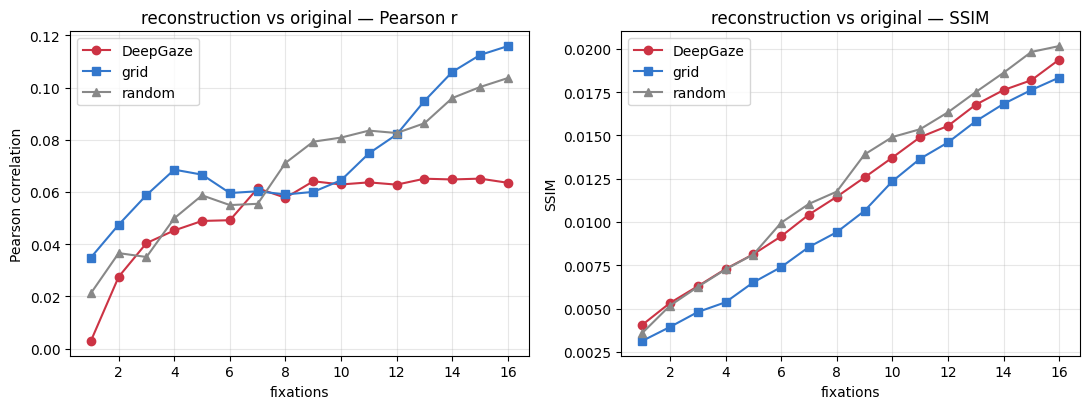

In [24]:
def similarity(reconstruction, target):
    a = reconstruction.astype(np.float32)
    b = target.astype(np.float32) / max(target.max(), 1e-6)
    if a.max() > 0:
        a = a / a.max()
    pearson = np.corrcoef(a.ravel(), b.ravel())[0, 1]
    ssim = ssim_metric(a, b, data_range=1.0)
    return pearson, ssim

def grid_scanpath(h, w, n):
    '''Snake-order grid of n fixations.'''
    side = int(np.ceil(np.sqrt(n)))
    xs = np.linspace(w * 0.15, w * 0.85, side)
    ys = np.linspace(h * 0.15, h * 0.85, side)
    pts = []
    for j, y in enumerate(ys):
        row = xs if j % 2 == 0 else xs[::-1]
        for x in row:
            pts.append((int(x), int(y)))
    return pts[:n]

def random_scanpath(h, w, n, seed=0):
    rng = np.random.default_rng(seed)
    return [(int(rng.uniform(w * 0.1, w * 0.9)),
             int(rng.uniform(h * 0.1, h * 0.9))) for _ in range(n)]

N_FIX = 16
sim_cmp = make_simulator(n_phosphenes=500, seed=0)
hist_grid   = walk(bus_gray, grid_scanpath(H, W, N_FIX), sim_cmp, fov_radius=56)
hist_random = walk(bus_gray, random_scanpath(H, W, N_FIX, seed=3), sim_cmp, fov_radius=56)

def curves(hist):
    pc, sc = [], []
    for c in hist:
        p, s = similarity(c, bus_gray)
        pc.append(p); sc.append(s)
    return np.array(pc), np.array(sc)

p_dg, s_dg   = curves(hist_dg)
p_gr, s_gr   = curves(hist_grid)
p_rn, s_rn   = curves(hist_random)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x_axis = np.arange(1, N_FIX + 1)
axes[0].plot(x_axis, p_dg, '-o', label='DeepGaze', color='#cc3344')
axes[0].plot(x_axis, p_gr, '-s', label='grid',     color='#3377cc')
axes[0].plot(x_axis, p_rn, '-^', label='random',   color='#888888')
axes[0].set_xlabel('fixations'); axes[0].set_ylabel('Pearson correlation')
axes[0].set_title('reconstruction vs original — Pearson r'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_axis, s_dg, '-o', label='DeepGaze', color='#cc3344')
axes[1].plot(x_axis, s_gr, '-s', label='grid',     color='#3377cc')
axes[1].plot(x_axis, s_rn, '-^', label='random',   color='#888888')
axes[1].set_xlabel('fixations'); axes[1].set_ylabel('SSIM')
axes[1].set_title('reconstruction vs original — SSIM'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**What you should see.** DeepGaze typically rises faster than the random strategy on both
metrics — its first few fixations land on informative parts of the scene (the bus front,
pedestrians), so the cumulative reconstruction explains the variance of the original
faster. The regular grid is a strong baseline: by construction it covers the whole image
uniformly, so it tends to overtake DeepGaze once you have enough fixations to tile the
scene. The interesting regime is **few fixations** — where every saccade has to count, gaze
prediction is doing real work.

Try re-running the cell with a different DeepGaze seed; the curves are stochastic but the
ranking near the start is fairly stable on this image.

### Exercise 4.1 — visualise the build-up `[easy]`

Plot the cumulative reconstruction at $C_1$, $C_5$, $C_{15}$ for the DeepGaze
strategy with the scanpath laid on top. Which regions fill in first?

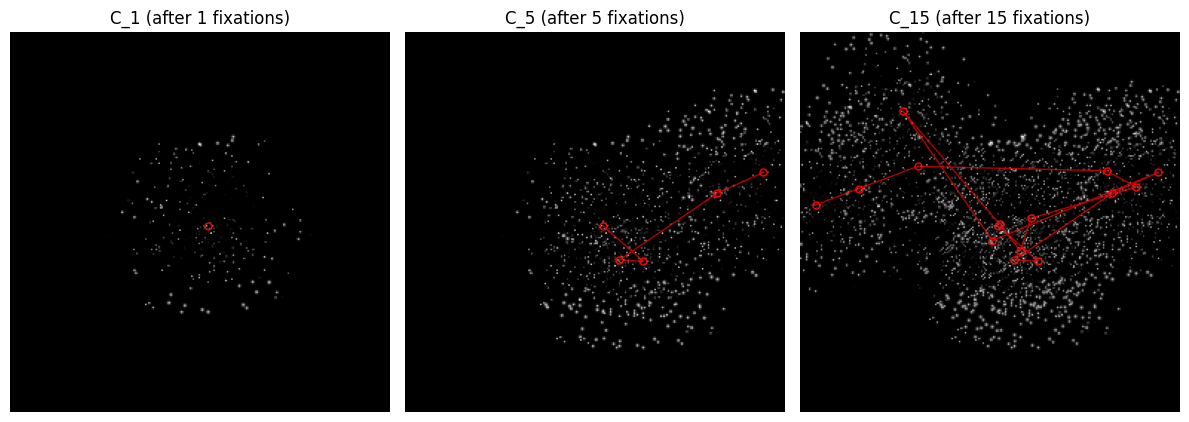

In [25]:
# Exercise 4.1 — DeepGaze build-up at milestones
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, i in zip(axes, [0, 4, 14]):
    ax.imshow(hist_dg[i], cmap='gray')
    xs = [p[0] for p in dg_path[:i+1]]; ys = [p[1] for p in dg_path[:i+1]]
    ax.plot(xs, ys, '-', color='red', lw=1, alpha=0.7)
    ax.plot(xs, ys, 'o', color='red', ms=5, mfc='none')
    ax.set_title(f'C_{i+1} (after {i+1} fixations)'); ax.axis('off')
plt.tight_layout(); plt.show()

### Exercise 4.2 — write your own `cumulative_similarity` `[intermediate]`

Write a function `cumulative_similarity(scanpath, image_gray, sim, fov_radius=56) -> (pearson, ssim)`
that runs `walk()` and returns the two arrays. Then reproduce the three-curve plot above
**on the astronaut image** rather than the bus. Does DeepGaze keep its early-fixation lead
when there is a face in the frame?

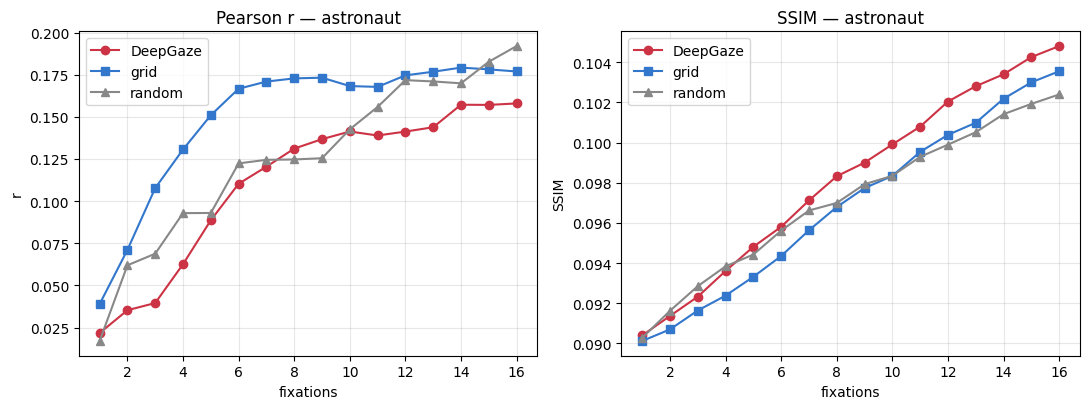

In [26]:
# Exercise 4.2 — cumulative_similarity on the astronaut
def cumulative_similarity(scanpath, image_gray, sim, fov_radius=56):
    hist = walk(image_gray, scanpath, sim, fov_radius=fov_radius)
    pc, sc = [], []
    for c in hist:
        p, s = similarity(c, image_gray)
        pc.append(p); sc.append(s)
    return np.array(pc), np.array(sc)

face_gray = cv2.cvtColor(face_rgb, cv2.COLOR_RGB2GRAY)
dg_face_path, _ = sample_scanpath(face_t, cb_t, n_fix=N_FIX, seed=4)
sim_face = make_simulator(n_phosphenes=500, seed=0)

p_dg_f, s_dg_f = cumulative_similarity(dg_face_path, face_gray, sim_face)
p_gr_f, s_gr_f = cumulative_similarity(grid_scanpath(H, W, N_FIX), face_gray, sim_face)
p_rn_f, s_rn_f = cumulative_similarity(random_scanpath(H, W, N_FIX, seed=5), face_gray, sim_face)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x_axis = np.arange(1, N_FIX + 1)
for vals, lbl, color, mk in [(p_dg_f, 'DeepGaze', '#cc3344', 'o'),
                              (p_gr_f, 'grid',     '#3377cc', 's'),
                              (p_rn_f, 'random',   '#888888', '^')]:
    axes[0].plot(x_axis, vals, '-'+mk, label=lbl, color=color)
for vals, lbl, color, mk in [(s_dg_f, 'DeepGaze', '#cc3344', 'o'),
                              (s_gr_f, 'grid',     '#3377cc', 's'),
                              (s_rn_f, 'random',   '#888888', '^')]:
    axes[1].plot(x_axis, vals, '-'+mk, label=lbl, color=color)
axes[0].set_title('Pearson r — astronaut'); axes[0].set_xlabel('fixations'); axes[0].set_ylabel('r'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('SSIM — astronaut'); axes[1].set_xlabel('fixations'); axes[1].set_ylabel('SSIM'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Exercise 4.3 — accumulator modes `[intermediate]`

The reconstruction depends on how you accumulate per-fixation phosphene images. Try
**sum** (every fixation adds, brightness can saturate) and a **mean over the fixations
that hit each pixel** (averages out noise but blurs sharp features). Compare reconstructions
and similarity curves.

*Hint: the `walk()` function takes a `mode` argument; `'mean'` is left as your TODO. The
trick for mean: keep a `count` canvas that increments where the new phosphene is non-zero,
and divide at the end.*

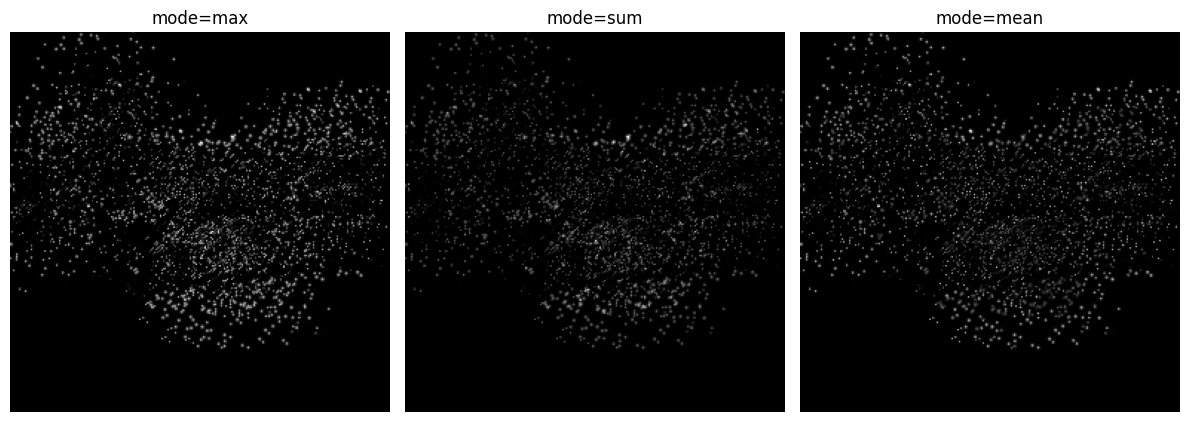

In [27]:
# Exercise 4.3 — sum vs running-mean accumulators
def walk_with_mode(image_gray, scanpath, sim, fov_radius=56, mode='sum'):
    canvas = None
    counts = None
    history = []
    for xy in scanpath:
        foved = foveate(image_gray, xy, fov_radius=fov_radius)
        phos = render_phosphenes(sim, foved)
        h, w = phos.shape
        M = np.float32([[1, 0, xy[0] - w / 2], [0, 1, xy[1] - h / 2]])
        phos_world = cv2.warpAffine(phos, M, (w, h), borderValue=0)
        if mode == 'sum':
            canvas = phos_world if canvas is None else canvas + phos_world
            history.append(canvas.copy())
        elif mode == 'mean':
            mask = (phos_world > 1e-4).astype(np.float32)
            canvas = phos_world.copy() if canvas is None else canvas + phos_world
            counts = mask.copy()   if counts is None else counts + mask
            avg = canvas / np.maximum(counts, 1)
            history.append(avg.copy())
    return history

hist_sum  = walk_with_mode(bus_gray, dg_path, make_simulator(500, seed=0), mode='sum')
hist_mean = walk_with_mode(bus_gray, dg_path, make_simulator(500, seed=0), mode='mean')

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(hist_dg[-1],   cmap='gray'); axes[0].set_title('mode=max'); axes[0].axis('off')
axes[1].imshow(hist_sum[-1],  cmap='gray'); axes[1].set_title('mode=sum'); axes[1].axis('off')
axes[2].imshow(hist_mean[-1], cmap='gray'); axes[2].set_title('mode=mean'); axes[2].axis('off')
plt.tight_layout(); plt.show()

### Exercise 4.4 — does DeepGaze's advantage scale with bandwidth? `[challenge]`

Re-run the three-strategy comparison at 100, 500, and 1000 electrodes. The hypothesis: with
very few electrodes, gaze prediction matters less (you can't render anything well anyway);
in the middle, DeepGaze wins clearly; at very high counts, even a random sampler converges
because every saccade adds substantial information. Confirm or refute on the bus.

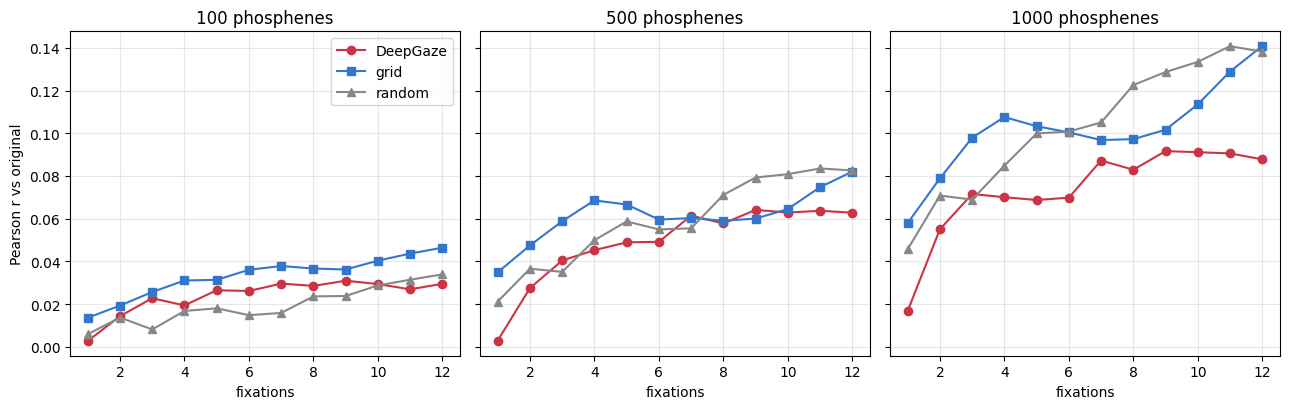

In [28]:
# Exercise 4.4 — DeepGaze vs random vs grid, sweeping electrode count
N_FIX_SWEEP = 12
results = {}
for n in (100, 500, 1000):
    sim_n = make_simulator(n_phosphenes=n, seed=0)
    p_dg_n, _ = cumulative_similarity(sample_scanpath(bus_t, cb_t, n_fix=N_FIX_SWEEP, seed=7)[0],
                                       bus_gray, sim_n)
    p_gr_n, _ = cumulative_similarity(grid_scanpath(H, W, N_FIX_SWEEP), bus_gray, sim_n)
    p_rn_n, _ = cumulative_similarity(random_scanpath(H, W, N_FIX_SWEEP, seed=3), bus_gray, sim_n)
    results[n] = (p_dg_n, p_gr_n, p_rn_n)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
x_axis = np.arange(1, N_FIX_SWEEP + 1)
for ax, n in zip(axes, results):
    p_dg_n, p_gr_n, p_rn_n = results[n]
    ax.plot(x_axis, p_dg_n, '-o', label='DeepGaze', color='#cc3344')
    ax.plot(x_axis, p_gr_n, '-s', label='grid',     color='#3377cc')
    ax.plot(x_axis, p_rn_n, '-^', label='random',   color='#888888')
    ax.set_title(f'{n} phosphenes'); ax.set_xlabel('fixations'); ax.grid(alpha=0.3)
axes[0].set_ylabel('Pearson r vs original'); axes[0].legend()
plt.tight_layout(); plt.show()

## 5 · Challenges  *(open-ended; lighter scaffolding)*

Three open extensions. No worked solutions in the markdown — try them yourself, and the
solution notebook just shows one possible answer per challenge.

### 5.1 — Peripheral Center Bias `[challenge]`

Build a **donut-shaped** Center Bias (low in the middle, high in a ring around it) and
rerun the DeepGaze scanpath. This roughly models a user with central scotoma (the centre
of the visual field is non-functional, so attention is biased to the periphery). What
changes in the scanpath?

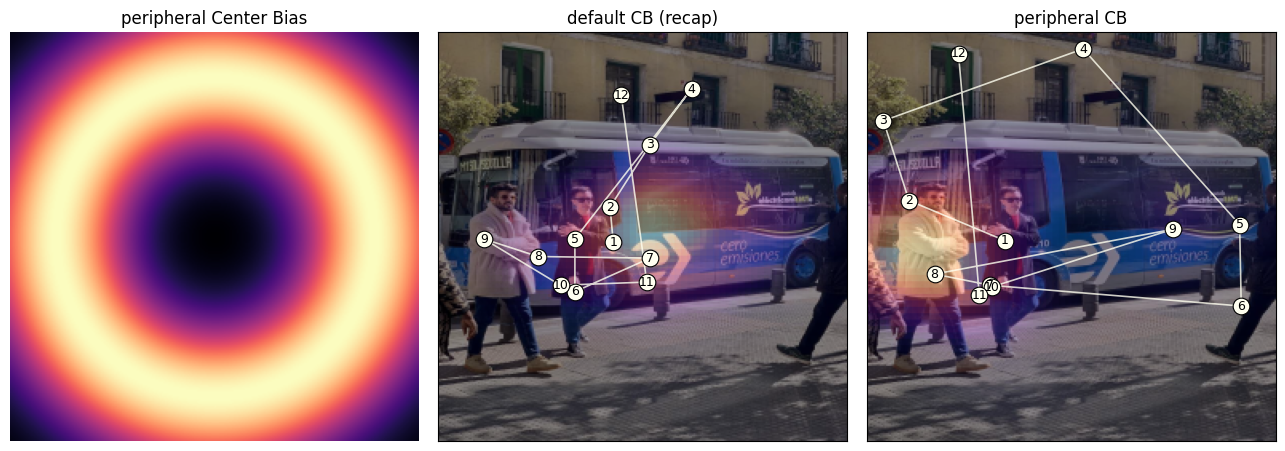

In [29]:
# 5.1 — peripheral Center Bias
yy, xx = np.mgrid[:H, :W]
r = np.hypot(xx - W / 2, yy - H / 2)
r_norm = r / r.max()
ring = np.exp(-((r_norm - 0.55) ** 2) / (2 * 0.18 ** 2))   # donut peaked at r=0.55
cb_ring = np.log(np.clip(ring, 1e-6, None))
cb_ring -= logsumexp(cb_ring)
cb_ring_t = torch.tensor(cb_ring[None].astype(np.float32)).to(device)

path_ring, dens_ring = sample_scanpath(bus_t, cb_ring_t, n_fix=12, seed=0)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(np.exp(cb_ring), cmap='magma'); axes[0].set_title('peripheral Center Bias'); axes[0].axis('off')
plot_scanpath(bus_rgb, path,      densities[-1], ax=axes[1], title='default CB (recap)')
plot_scanpath(bus_rgb, path_ring, dens_ring[-1], ax=axes[2], title='peripheral CB')
plt.tight_layout(); plt.show()

### 5.2 — Continue a real eye-tracking prefix `[challenge]`

You measured three fixations from a real user looking at the bus. Seed the history with
those exact fixations and continue the scanpath for 10 more steps. This is how you'd
predict where the user is *about* to look next, given what they just looked at.

A representative prefix is provided below; replace it with your own measurements when you
have them.

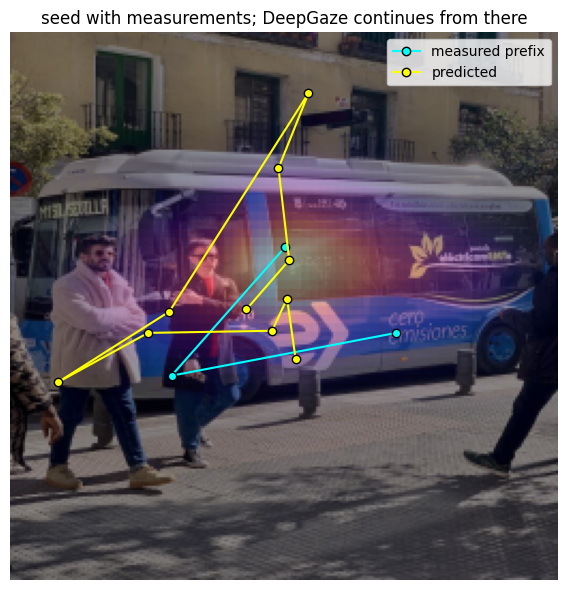

In [30]:
# 5.2 — seed history with measured fixations, then predict the next 10
measured = [(128, 100), (75, 160), (180, 140)]   # placeholder prefix
def sample_scanpath_with_prefix(image_tensor, cb_tensor, prefix, n_more=10, seed=0):
    rng = np.random.default_rng(seed)
    history = list(prefix)
    densities = []
    for _ in range(n_more):
        log_d = deepgaze_density(image_tensor, cb_tensor, history)
        p = np.exp(log_d); p /= p.sum()
        densities.append(p)
        x, y = sample_fixation(p, rng)
        history.append((x, y))
    return history, densities

full_path, dens_full = sample_scanpath_with_prefix(bus_t, cb_t, measured, n_more=10, seed=0)
plt.figure(figsize=(6, 6))
ax = plt.gca()
ax.imshow(bus_rgb); ax.imshow(dens_full[-1], cmap='magma', alpha=0.45)
# measured prefix in cyan, predicted in yellow
mx = [p[0] for p in measured]; my = [p[1] for p in measured]
px = [p[0] for p in full_path[len(measured):]]; py = [p[1] for p in full_path[len(measured):]]
ax.plot(mx, my, '-o', color='cyan', mec='black', label='measured prefix')
ax.plot(px, py, '-o', color='yellow', mec='black', label='predicted')
ax.legend(); ax.axis('off')
ax.set_title('seed with measurements; DeepGaze continues from there')
plt.tight_layout(); plt.show()

### 5.3 — Motor jitter `[challenge]`

Real human fixations are noisy — the eye does not land exactly where it intended. Add
Gaussian noise (sd ~ 4 pixels, the order of typical microsaccades) to each DeepGaze-sampled
fixation *before* you pass it to `foveate()`. How much does this degrade the cumulative
Pearson correlation curve?

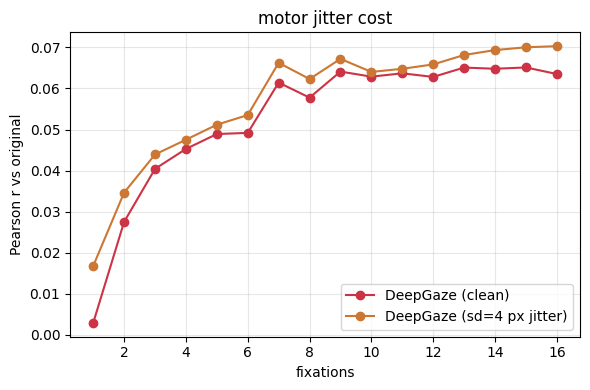

In [31]:
# 5.3 — DeepGaze with motor jitter
def jittered_scanpath(scanpath, sd=4.0, seed=0):
    rng = np.random.default_rng(seed)
    return [(int(np.clip(p[0] + rng.normal(0, sd), 0, W - 1)),
             int(np.clip(p[1] + rng.normal(0, sd), 0, H - 1))) for p in scanpath]

clean = sample_scanpath(bus_t, cb_t, n_fix=N_FIX, seed=7)[0]
jittered = jittered_scanpath(clean, sd=4.0, seed=11)
sim_j = make_simulator(n_phosphenes=500, seed=0)
p_clean, _ = cumulative_similarity(clean,    bus_gray, sim_j)
p_jitter, _ = cumulative_similarity(jittered, bus_gray, sim_j)

plt.figure(figsize=(6, 4))
x_axis = np.arange(1, N_FIX + 1)
plt.plot(x_axis, p_clean,  '-o', label='DeepGaze (clean)', color='#cc3344')
plt.plot(x_axis, p_jitter, '-o', label='DeepGaze (sd=4 px jitter)', color='#cc7733')
plt.xlabel('fixations'); plt.ylabel('Pearson r vs original'); plt.legend(); plt.grid(alpha=0.3)
plt.title('motor jitter cost')
plt.tight_layout(); plt.show()

## Where to next

You've now done end-to-end what the HTML page laid out conceptually:

- Run DeepGaze III on real images and produced heatmaps that match human attention.
- Sampled scanpaths and recovered the same saccade-length and saccade-angle distributions
  the HTML page synthesised from literature.
- Plugged gaze into the real `dynaphos` simulator and watched the **sliding effect** appear
  and disappear depending on whether the renderer is gaze-contingent.
- **Quantified** how much gaze prediction is worth: with informed sampling, ~5 well-chosen
  fixations match what ~10 random ones cover.

Next module: **M3 — Neuromodulation & stimulation**, where the patch of scene you just
decided to look at becomes an actual stimulation pattern across the electrodes you saw
`dynaphos` simulate here.